In [4]:
import json
import torch
from huggingface_hub import hf_hub_download
from transformers import AutoFeatureExtractor, Data2VecAudioConfig, Data2VecAudioModel, Wav2Vec2Model
import utils
import random
import matplotlib.pyplot as plt
import numpy as np

# 1. Load the model and feature extractor
########## SPEECH TRAINED ###########
# model_name = "facebook/wav2vec2-base-960h"
# feature_extractor = AutoFeatureExtractor.from_pretrained(model_name)
# model = Wav2Vec2Model.from_pretrained(
#     model_name,
#     attn_implementation="eager"  # Forces explicit output of full attention matrices
# )
##########################

##### MUSIC TRAINED #####
model_name = "facebook/data2vec-audio-base-960h"
feature_extractor = AutoFeatureExtractor.from_pretrained(model_name)

# The uploaded music2vec config contains a malformed vocab_size value in some
# environments, so we repair it before constructing the model.
config_path = hf_hub_download(repo_id="m-a-p/music2vec-v1", filename="config.json")
with open(config_path, "r", encoding="utf-8") as f:
    config_dict = json.load(f)
config_dict["vocab_size"] = 32
config = Data2VecAudioConfig(**config_dict)
config._attn_implementation = 'eager'
config.output_attentions = True

model = Data2VecAudioModel.from_pretrained(
    "m-a-p/music2vec-v1",
    config=config,
)
########################

model.eval()

# 2. Define audio file paths
audio_paths = [
    "../music-clips/classical_1.wav",
    "../music-clips/classical_2.wav",
    "../music-clips/classical_3.wav",
    "../music-clips/electronic_1.wav",
    "../music-clips/electronic_2.wav",
    "../music-clips/bleep.wav",
    "../music-clips/sa01.wav",
    "../music-clips/sa02.wav"
]
waveforms = utils.load_process_bulk_audio(audio_paths)
inputs_dict = utils.process_bulk_wave2vec(waveforms, feature_extractor)

# 3. Extract attention weights per audio file
attentions_dict = {}

with torch.no_grad():
    for path, inputs in inputs_dict.items():
        outputs = model(
            inputs.input_values,
            output_attentions=True,
            output_hidden_states=True
            )
        # outputs.attentions is a tuple of (num_layers,) tensors,
        # each with shape: (batch_size, num_heads, sequence_length, sequence_length)
        # Stack into a single tensor of shape: [num_layers, num_heads, seq_len, seq_len]
        attentions_tensor = torch.stack(outputs.attentions).squeeze(1)
        attentions_dict[path] = attentions_tensor

Loading weights:   0%|          | 0/230 [00:00<?, ?it/s]

In [ ]:
mad_dict = {}
for path, attn in attentions_dict.items():
    seq_length = attn.shape[-1]
    print(path, seq_length)
    mean_distances = utils.compute_mad_by_layer(attn, seq_length)
    mad_dict[path] = mean_distances

../music-clips/classical_1.wav 3001
../music-clips/classical_2.wav 3001
../music-clips/classical_3.wav 3001
../music-clips/electronic_1.wav 2999
../music-clips/electronic_2.wav 2999
../music-clips/bleep.wav 1501
../music-clips/sa01.wav 544
../music-clips/sa02.wav 544


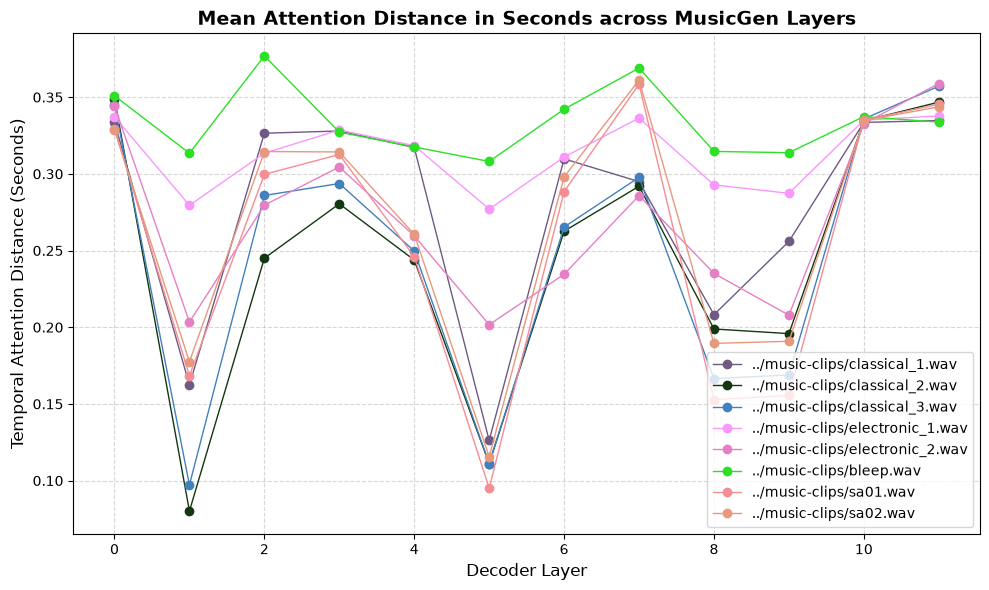

In [ ]:
plt.figure(figsize=(10, 6))

for path, mads in mad_dict.items():
    random_hex = f"#{random.randint(0, 0xFFFFFF):06x}"
    num_layers = len(attentions_dict.get(path))
    layer_averages_sec = np.mean(mads, axis=1)
    plt.plot(range(num_layers), layer_averages_sec, color=random_hex, linewidth=1, marker='o', label=path)


plt.title("Mean Attention Distance Percentage across Wave2Vec Layers", fontsize=14, fontweight='bold')
plt.xlabel("Layer", fontsize=12)
plt.ylabel("Temporal Attention Distance (Percentage of Clip)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()